<a href="https://colab.research.google.com/github/fbkaragoz/notebooks/blob/main/eksi_eda_25_12_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import gzip
import csv

FILE_PATH = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz"

COLUMNS = [
    "id", "topic_id", "topic_title", "author_hash", "favorites",
    "created_at", "created_at_raw", "text", "text_hash", "url",
    "crawled_at", "run_id"
]


In [12]:
def stream_eksi_entries(file_path):
  inside_copy_block = False

  with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
    for line in f:
      if not inside_copy_block:
        if line.startswith("COPY public.entries"):
          inside_copy_block = True
        continue

      if line.strip() == '\.':
        print("End of copy block")
        break

      row_values = line.strip().split('\t')
      if len(row_values) == len(COLUMNS):
        yield dict(zip(COLUMNS, row_values))

print("engine testing")

data_generator = stream_eksi_entries(FILE_PATH)

engine testing


<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-2503630658.py:11: SyntaxWarning: invalid escape sequence '\.'
  if line.strip() == '\.':


In [13]:
try:
  for _ in range(3):
    entry = next(data_generator)
    print(f"Entry ID: {entry['id']}")
    print(f"Title: {entry['topic_title']}")
    print(f"Text: {entry['text'][:50]}")
except StopIteration:
  print('No data available')

Entry ID: 37044062
Title: adolf hitler'in en büyük hatası85
Text: (bkz: israili kurdurtması )
Entry ID: 37044115
Title: adolf hitler'in en büyük hatası85
Text: gittigi berberi.
Entry ID: 37044643
Title: adolf hitler'in en büyük hatası85
Text: bıyık seçimi


[INFO] Starting FULL SCAN of /content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz...
[INFO] This will process the entire 10GB. Please wait...
[INFO] Data block found. Analysis started.
[RUNNING] Processed 8.0 Million rows...[INFO] Reached end of data block.

[DONE] Total rows processed: 8477520
[INFO] Generating Yearly Chart...
[INFO] Generating All-Time Top Topics Chart...


/tmp/ipython-input-223364926.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(topics), ax=axes[1], palette='magma')


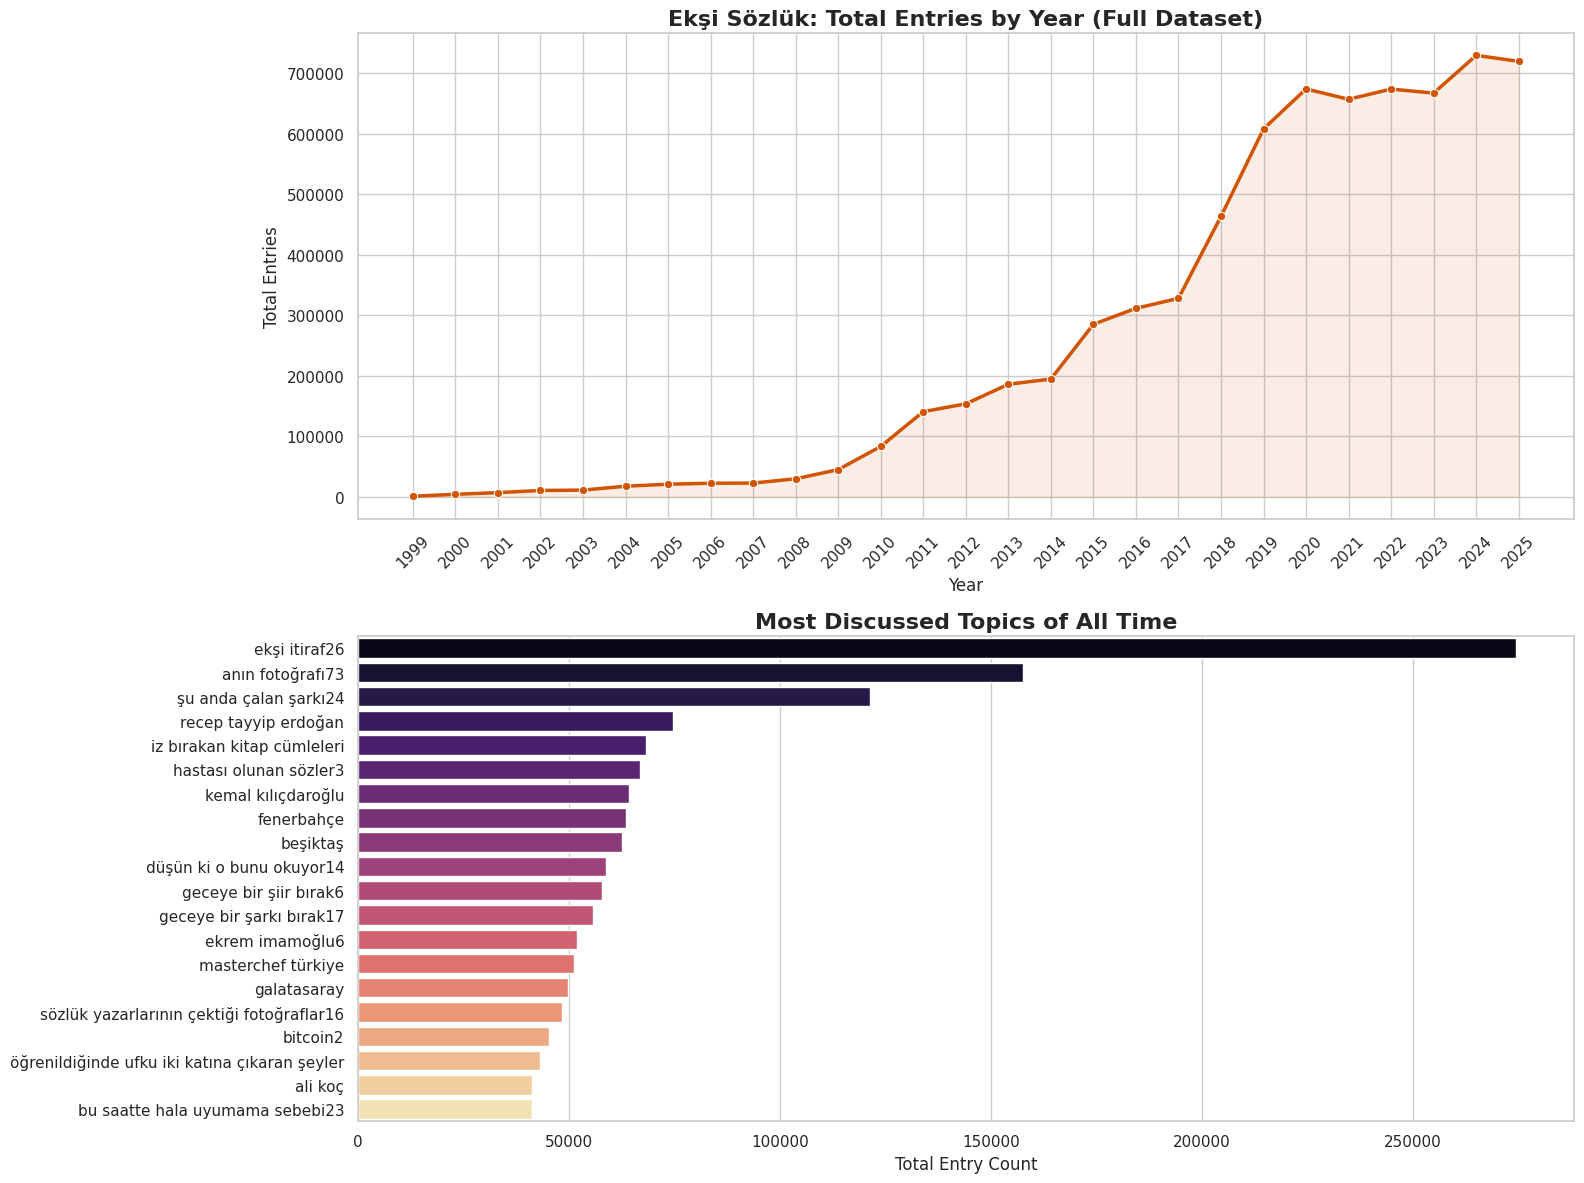

In [23]:
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
import sys

# Constants
FILE_PATH = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz"

# Indices based on the schema we found earlier:
# 0: id, 1: topic_id, 2: topic_title, ..., 5: created_at, ...
IDX_TOPIC_TITLE = 2
IDX_CREATED_AT = 5

def analyze_full_dataset(file_path):
    # Specialized lightweight counters
    year_counter = Counter()
    topic_counter = Counter()

    line_count = 0
    inside_data_block = False

    print(f"[INFO] Starting FULL SCAN of {file_path}...")
    print("[INFO] This will process the entire 10GB. Please wait...")

    try:
        with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                # 1. Fast Block Detection
                if not inside_data_block:
                    if "COPY" in line and "entries" in line:
                        inside_data_block = True
                        print("[INFO] Data block found. Analysis started.")
                    continue

                # 2. End of Block Check
                if line.strip() == r'\.':
                    print("[INFO] Reached end of data block.")
                    break

                # 3. Fast Parsing (No Dictionaries, direct indexing for speed)
                row = line.split('\t')

                # Safety check for column count (len should be 12)
                if len(row) < 6:
                    continue

                # --- EXTRACT DATA ---

                # A. Year Processing
                raw_date = row[IDX_CREATED_AT]
                # format is usually "2001-08-25 15:00:00..."
                if len(raw_date) >= 4:
                    year = raw_date[:4] # Take just "2001"
                    if year.isdigit() and 1999 <= int(year) <= 2025: # Basic data sanity check
                        year_counter[year] += 1

                # B. Topic Processing
                topic = row[IDX_TOPIC_TITLE]
                if topic:
                    topic_counter[topic] += 1

                # 4. Progress Bar
                line_count += 1
                if line_count % 1000000 == 0:
                    # Print progress every 1 million rows so you know it's not frozen
                    sys.stdout.write(f"\r[RUNNING] Processed {line_count / 1000000:.1f} Million rows...")
                    sys.stdout.flush()

    except Exception as e:
        print(f"\n[ERROR] Stream interrupted: {e}")

    print(f"\n[DONE] Total rows processed: {line_count}")
    return year_counter, topic_counter

# --- EXECUTION ---

# 1. Run the heavy lifting
years_count, topics_count = analyze_full_dataset(FILE_PATH)

if years_count:
    # 2. Visualization Setup
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # --- CHART 1: Yearly Volume (Full Data) ---
    print("[INFO] Generating Yearly Chart...")

    # Convert counter to DataFrame for sorting
    df_years = pd.DataFrame.from_dict(years_count, orient='index', columns=['count'])
    df_years.index = df_years.index.astype(int)
    df_years = df_years.sort_index()

    # Plot
    sns.lineplot(x=df_years.index, y=df_years['count'], ax=axes[0], color='#d35400', marker="o", linewidth=2.5)
    axes[0].set_title('Ekşi Sözlük: Total Entries by Year (Full Dataset)', fontsize=16, fontweight='bold')
    axes[0].set_ylabel('Total Entries')
    axes[0].set_xlabel('Year')
    axes[0].set_xticks(df_years.index) # Show every year tick
    axes[0].tick_params(axis='x', rotation=45)

    # Fill area under line for better visuals
    axes[0].fill_between(df_years.index, df_years['count'], color='#d35400', alpha=0.1)

    # --- CHART 2: All-Time Top Topics ---
    print("[INFO] Generating All-Time Top Topics Chart...")

    # Get top 20 topics from the entire history
    top_topics = topics_count.most_common(20)
    topics, counts = zip(*top_topics)

    sns.barplot(x=list(counts), y=list(topics), ax=axes[1], palette='magma')
    axes[1].set_title('Most Discussed Topics of All Time', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Total Entry Count')

    plt.tight_layout()
    plt.show()

else:
    print("[WARNING] No data found. Please check the file format again.")

[INFO] Starting BEHAVIORAL SCAN of /content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz...
[INFO] Data block found. Extracting timestamps and lengths...
[RUNNING] Processed 8.0 Million rows...
[DONE] Behavioral analysis complete.
[INFO] Generating Heatmap...
[INFO] Generating Verbosity Trend...


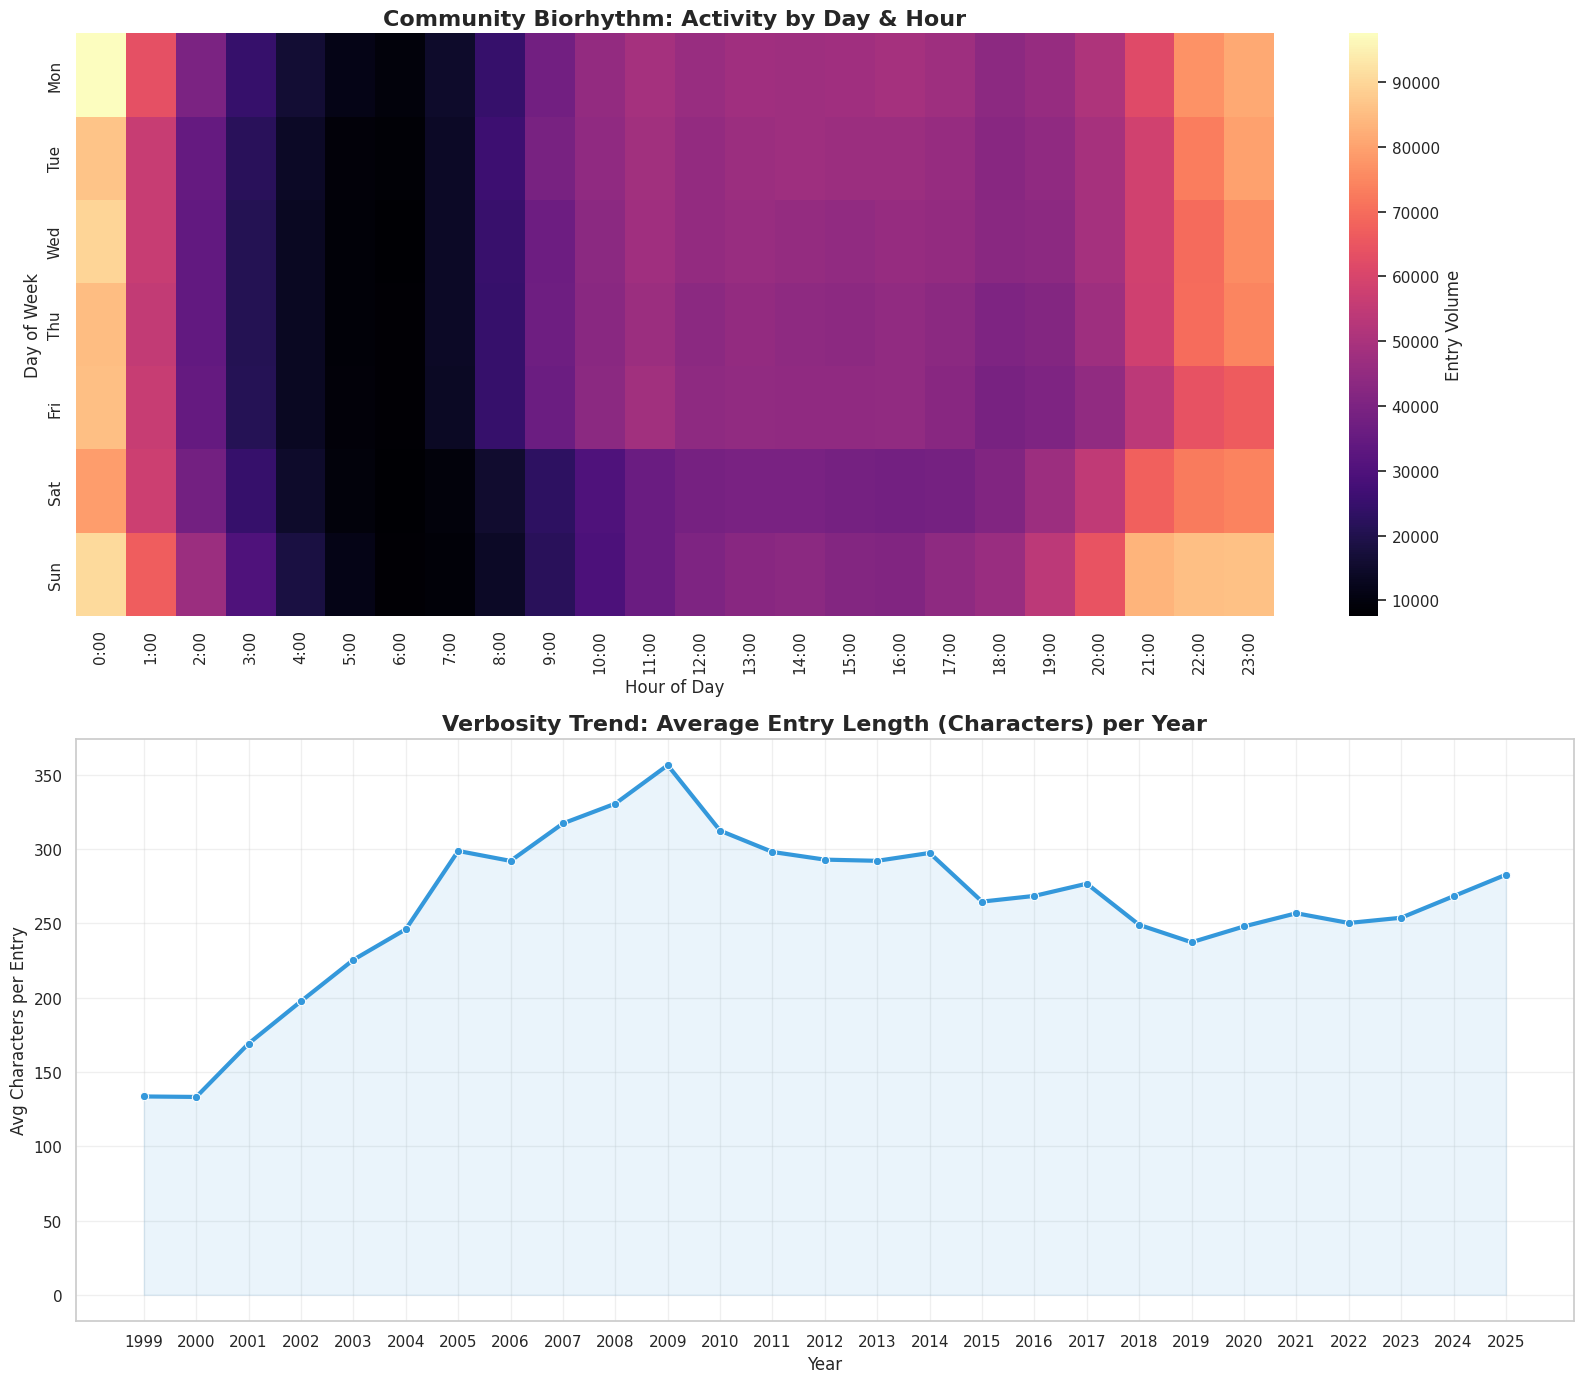

In [24]:
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
from datetime import datetime

# Constants
FILE_PATH = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz"
IDX_CREATED_AT = 5
IDX_TEXT = 7

def analyze_behavior(file_path):
    # Matrix for Heatmap: 7 Days x 24 Hours
    # rows: days (0=Mon, 6=Sun), cols: hours (0-23)
    heatmap_data = [[0] * 24 for _ in range(7)]

    # Verbosity Tracking: {Year: [total_length, entry_count]}
    verbosity_data = {}

    line_count = 0
    inside_data_block = False

    print(f"[INFO] Starting BEHAVIORAL SCAN of {file_path}...")

    try:
        with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if not inside_data_block:
                    if "COPY" in line and "entries" in line:
                        inside_data_block = True
                        print("[INFO] Data block found. Extracting timestamps and lengths...")
                    continue

                if line.strip() == r'\.':
                    break

                row = line.split('\t')
                if len(row) < 8: continue

                # --- PARSING ---
                raw_date = row[IDX_CREATED_AT] # "2001-08-25 15:00:00..."
                text_content = row[IDX_TEXT]

                if len(raw_date) >= 19:
                    try:
                        # String slicing is faster than datetime parsing for simple parts
                        # Structure: YYYY-MM-DD HH:MM:SS
                        year_str = raw_date[:4]
                        hour_str = raw_date[11:13]

                        # Only parse full date for weekday calculation (slightly expensive but necessary)
                        # We use a try-except block just in case of weird formats
                        dt_obj = datetime.fromisoformat(raw_date[:19])
                        weekday = dt_obj.weekday() # 0=Monday
                        hour = int(hour_str)
                        year = int(year_str)

                        # 1. Fill Heatmap Data
                        heatmap_data[weekday][hour] += 1

                        # 2. Fill Verbosity Data
                        length = len(text_content)
                        if year not in verbosity_data:
                            verbosity_data[year] = [0, 0] # [total_len, count]
                        verbosity_data[year][0] += length
                        verbosity_data[year][1] += 1

                    except ValueError:
                        continue # Skip malformed dates

                # Progress
                line_count += 1
                if line_count % 1000000 == 0:
                    sys.stdout.write(f"\r[RUNNING] Processed {line_count / 1000000:.1f} Million rows...")
                    sys.stdout.flush()

    except Exception as e:
        print(f"\n[ERROR] {e}")

    print(f"\n[DONE] Behavioral analysis complete.")
    return heatmap_data, verbosity_data

# --- EXECUTION & VISUALIZATION ---

heatmap_matrix, verbosity_dict = analyze_behavior(FILE_PATH)

if verbosity_dict:
    # Set up the figure
    fig, axes = plt.subplots(2, 1, figsize=(16, 14))
    sns.set_theme(style="white")

    # --- CHART 1: Community Biorhythm (Heatmap) ---
    print("[INFO] Generating Heatmap...")
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    # Create DataFrame for Heatmap
    df_heat = pd.DataFrame(heatmap_matrix, index=days, columns=[f"{h}:00" for h in range(24)])

    # Normalize by row (optional, but raw counts are usually fine for this scale)
    sns.heatmap(df_heat, cmap="magma", ax=axes[0], cbar_kws={'label': 'Entry Volume'})
    axes[0].set_title('Community Biorhythm: Activity by Day & Hour', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Day of Week')

    # --- CHART 2: The "Twitterization" Effect (Avg Length per Year) ---
    print("[INFO] Generating Verbosity Trend...")
    years = sorted(verbosity_dict.keys())
    avg_lengths = [verbosity_dict[y][0] / verbosity_dict[y][1] for y in years if y >= 1999] # Filter noise years
    clean_years = [y for y in years if y >= 1999]

    sns.lineplot(x=clean_years, y=avg_lengths, ax=axes[1], color="#3498db", linewidth=3, marker="o")
    axes[1].fill_between(clean_years, avg_lengths, color="#3498db", alpha=0.1)
    axes[1].set_title('Verbosity Trend: Average Entry Length (Characters) per Year', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Avg Characters per Entry')
    axes[1].set_xlabel('Year')
    axes[1].set_xticks(clean_years)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("[WARNING] No data gathered.")

In [25]:
import gzip
import pandas as pd
import math
import re
from collections import Counter
import sys

# --- SABİTLER VE AYARLAR ---
FILE_PATH = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz"

# Basit bir Türkçe Stopwords (Etkisiz Kelimeler) listesi
# Bunları analizden atacağız ki "gerçek" içerik kalsın.
STOPWORDS = set([
    "bir", "ve", "bu", "ne", "da", "de", "için", "çok", "ama", "o", "ile",
    "ben", "gibi", "var", "yok", "mi", "mı", "mu", "mü", "daha", "en", "kadar",
    "diye", "bile", "ise", "olan", "olarak", "sonra", "böyle", "kendi", "bunu",
    "onu", "bana", "sen", "siz", "biz", "her", "şey", "nasıl", "neden", "ki",
    "diğer", "bazı", "tüm", "şimdi", "hiç", "sadece", "veya", "ya", "ama",
    "belki", "artık", "zaten", "olsa", "öyle", "oldu", "olur", "olduğu", "entry"
])

def tokenize(text):
    """Metni kelimelere böler, küçültür ve temizler."""
    if not text: return []
    # Sadece harfleri al, sayıları ve noktalamayı at.
    words = re.findall(r'[a-zçğıöşü]+', text.lower())
    # Stopwords hariç ve 2 harften uzun kelimeleri al
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def get_yearly_keywords(file_path):
    # Veri Yapısı: {Yıl: Counter({kelime: sayı})}
    year_vocab = {}

    line_count = 0
    inside_data_block = False

    print(f"[INFO] Yıllara göre kelime analizi başlıyor (TF-IDF Mantığı)...")

    try:
        with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if not inside_data_block:
                    if "COPY" in line and "entries" in line:
                        inside_data_block = True
                    continue

                if line.strip() == r'\.':
                    break

                row = line.split('\t')
                # Index 2: topic_title (Başlık), Index 5: created_at
                if len(row) < 6: continue

                # Tarihi al
                raw_date = row[5]
                title = row[2]

                if len(raw_date) >= 4:
                    year = raw_date[:4]

                    # Veri temizliği: Sadece mantıklı yılları alalım
                    if year.isdigit() and 1999 <= int(year) <= 2025:

                        # Eğer bu yıl ilk kez görülüyorsa Counter oluştur
                        if year not in year_vocab:
                            year_vocab[year] = Counter()

                        # Başlığı kelimelerine ayır ve say
                        tokens = tokenize(title)
                        year_vocab[year].update(tokens)

                line_count += 1
                if line_count % 1000000 == 0:
                     sys.stdout.write(f"\r[İŞLENİYOR] {line_count / 1000000:.1f} Milyon satır tarandı...")
                     sys.stdout.flush()

    except Exception as e:
        print(f"\n[HATA] {e}")

    print(f"\n[TAMAMLANDI] Toplam {line_count} satır işlendi.")
    return year_vocab

# --- TF-IDF HESAPLAMA MOTORU ---

def calculate_tfidf_and_show(year_vocab):
    print("[ANALİZ] TF-IDF Skorları Hesaplanıyor...")

    # 1. Toplam Doküman Sayısı (Burada Doküman = Yıl)
    total_years = len(year_vocab)

    # 2. Her kelimenin kaç farklı yılda geçtiğini bul (Document Frequency)
    # Bu biraz ağır olabilir, o yüzden sadece her yılın top 5000 kelimesini alalım.
    doc_freq = Counter()

    for year, counter in year_vocab.items():
        # Set kullanarak o yıl içinde kelime 1000 kere de geçse 1 sayıyoruz (Binary)
        unique_words_in_year = set(counter.keys())
        doc_freq.update(unique_words_in_year)

    # Sonuçları saklayacağımız liste
    results = []

    for year, counter in year_vocab.items():
        total_words_in_year = sum(counter.values())

        for word, count in counter.most_common(200): # Her yılın en popüler 200 kelimesini aday yap

            # TF: Term Frequency (O yılda ne kadar yoğun?)
            # Normalize TF: count / total_words_in_year
            tf = count / total_words_in_year

            # IDF: Inverse Document Frequency (Ne kadar nadir?)
            # Kelime kaç yılda geçmiş?
            df_count = doc_freq[word]
            idf = math.log(total_years / (df_count + 1)) # +1 sıfıra bölünme hatası olmasın diye

            # Skor
            tfidf_score = tf * idf

            results.append({
                'year': year,
                'word': word,
                'score': tfidf_score,
                'count': count
            })

    # DataFrame'e çevir
    df = pd.DataFrame(results)

    # --- SONUÇLARI GÖSTER ---
    unique_years = sorted(df['year'].unique())

    print("\n" + "="*50)
    print("   YILLARA GÖRE EKŞİ SÖZLÜK'ÜN 'RUHUNU' YANSITAN KELİMELER")
    print("   (TF-IDF Yöntemi ile Normalize Edilmiştir)")
    print("="*50 + "\n")

    for year in unique_years:
        # O yılın en yüksek skorlu 5 kelimesini getir
        top_words = df[df['year'] == year].sort_values(by='score', ascending=False).head(5)

        words_str = ", ".join([f"{row['word']} ({row['count']})" for _, row in top_words.iterrows()])
        print(f"📅 {year}: {words_str}")

# --- ÇALIŞTIR ---
data = get_yearly_keywords(FILE_PATH)
if data:
    calculate_tfidf_and_show(data)

[INFO] Yıllara göre kelime analizi başlıyor (TF-IDF Mantığı)...
[İŞLENİYOR] 8.0 Milyon satır tarandı...
[TAMAMLANDI] Toplam 8477520 satır işlendi.
[ANALİZ] TF-IDF Skorları Hesaplanıyor...

   YILLARA GÖRE EKŞİ SÖZLÜK'ÜN 'RUHUNU' YANSITAN KELİMELER
   (TF-IDF Yöntemi ile Normalize Edilmiştir)

📅 1999: booster (7), isp (33), müşterisi (33), eowyn (5), sabrina (5)
📅 2000: moby (9), radiohead (8), orbital (8), bono (8), ari (9)
📅 2001: icq (31), moronları (31), müşterisi (18), isp (18), dublajlar (13)
📅 2002: başlayacaklara (128), tavsiyeler (128), üniversiteye (128), içtim (51), kapuçinoyu (51)
📅 2003: terminator (21), özetlemek (71), saniyede (71), içtim (58), öptüm (58)
📅 2004: itirafçıların (263), abeylegesse (101), anladığı (124), kişinin (124), büyüdüğünü (103)
📅 2005: itirafçıların (855), teorileri (543), gündelik (543), kazaz (103), değiştirmesi (103)
📅 2006: itirafçıların (757), düz (576), gündelik (547), teorileri (547), esprileri (75)
📅 2007: cska (104), moskova (104), sonuçları

In [27]:
import gzip
import pandas as pd
import math
import re
from collections import Counter
import sys

# --- 1. AYARLAR & SABİTLER ---
FILE_PATH = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz"

# Gürültü Kelimeleri (Platform Jargonu + Fiiller + Zaman Zarfları)
# Bunları manuel olarak genişlettik çünkü bunlar "topic" değil "format" kelimesi.
NOISE_WORDS = {
    "bir", "ve", "bu", "ne", "da", "de", "için", "çok", "ama", "o", "ile",
    "ben", "gibi", "var", "yok", "mi", "mı", "mu", "mü", "daha", "en", "kadar",
    "diye", "bile", "ise", "olan", "olarak", "sonra", "böyle", "kendi", "bunu",
    "onu", "bana", "sen", "siz", "biz", "her", "şey", "nasıl", "neden", "ki",
    "diğer", "bazı", "tüm", "şimdi", "hiç", "sadece", "veya", "ya", "ama",
    "belki", "artık", "zaten", "olsa", "öyle", "oldu", "olur", "olduğu", "entry",
    "hakkında", "ilgili", "yüzden", "lazım", "gereken", "kere", "tane",
    # Platforma özel "format" gürültüleri:
    "bırak", "geceye", "fotoğrafı", "anın", "yazarların", "sözlük", "yazar",
    "başlık", "tanım", "sorunsalı", "beyanı", "önerileri", "tavsiyeleri",
    "gelen", "giden", "eden", "alan", "yapan", "düşün", "okuyor"
}

# --- 2. YARDIMCI FONKSİYONLAR ---

def is_verb_like(word):
    """
    Basit bir 'heuristic' (sezgisel) kontrol.
    Kelime fiil gibi mi duruyor? (mek, mak, yor, dığı...)
    Bu %100 çalışmaz ama büyük gürültüyü engeller.
    """
    suffixes = ('mek', 'mak', 'yor', 'dığı', 'diği', 'tuğu', 'tüğü', 'acak', 'ecek', 'malı', 'meli')
    return word.endswith(suffixes)

def tokenize(text):
    if not text: return []
    # 1. Temizlik
    words = re.findall(r'[a-zçğıöşü]+', text.lower())

    clean_words = []
    for w in words:
        # 2. Filtreleme Zinciri
        if w in NOISE_WORDS: continue      # Yasaklı kelime mi?
        if len(w) < 3: continue            # Çok kısa mı?
        if is_verb_like(w): continue       # Fiil gibi mi? (Opsiyonel, duruma göre aç/kapa)

        clean_words.append(w)

    return clean_words

def stream_and_count(file_path):
    year_vocab = {} # {2001: Counter({'kelime': 50}), ...}
    line_count = 0
    inside_block = False

    print(f"[INFO] Akıllı Ayrıştırma Başlıyor: {file_path}")
    print("[INFO] Fiil benzeri kelimeler ve format jargonları eleniyor...")

    try:
        with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                # COPY bloğu bulma (Hızlı yöntem)
                if not inside_block:
                    if "COPY" in line and "entries" in line:
                        inside_block = True
                    continue

                if line.strip() == r'\.':
                    break

                parts = line.split('\t')
                if len(parts) < 6: continue

                # Sütunlar: 2=Title, 5=Created_At
                raw_date = parts[5]
                title = parts[2]

                if len(raw_date) >= 4:
                    year = raw_date[:4]
                    if year.isdigit() and 1999 <= int(year) <= 2025:

                        if year not in year_vocab:
                            year_vocab[year] = Counter()

                        tokens = tokenize(title)
                        year_vocab[year].update(tokens)

                line_count += 1
                if line_count % 1000000 == 0:
                    sys.stdout.write(f"\r[OKUNUYOR] {line_count / 1000000:.1f} Milyon satır...")
                    sys.stdout.flush()

    except Exception as e:
        print(f"\n[HATA] {e}")

    print(f"\n[BİTTİ] Toplam {line_count} satır analiz edildi.")
    return year_vocab

# --- 3. AKILLI TF-IDF ANALİZİ ---

def smart_tfidf_analysis(year_vocab, max_df_ratio=0.6):
    """
    max_df_ratio: Bir kelime yılların %60'ından fazlasında geçiyorsa atılır.
    """
    print("[ANALİZ] İstatistikler hesaplanıyor...")

    total_years = len(year_vocab)
    doc_freq = Counter()

    # 1. Global Görünürlük Hesapla (Hangi kelime kaç yılda var?)
    for year, counter in year_vocab.items():
        doc_freq.update(counter.keys())

    results = []

    for year, counter in year_vocab.items():
        total_tokens = sum(counter.values())
        if total_tokens == 0: continue

        # O yılın en popüler 500 kelimesini aday olarak al
        for word, count in counter.most_common(500):

            # --- SMART FILTERING ---
            df = doc_freq[word]

            # Kural 1: Çok nadirleri at (Sadece 1 yılda 1 kere geçmişse gürültüdür)
            if count < 3: continue

            # Kural 2: Çok yaygınları at (Stopword olmasa bile her yıl konuşulanlar)
            # Örn: "kız", "erkek", "türkiye", "insan" -> Bunlar olay değildir.
            if df > (total_years * max_df_ratio):
                continue

            # --- MATEMATİK ---
            tf = count / total_tokens
            idf = math.log(total_years / (df + 1))
            score = tf * idf

            results.append({
                'year': year,
                'word': word,
                'score': score,
                'count': count
            })

    return pd.DataFrame(results)

# --- ÇALIŞTIR ---

vocab_data = stream_and_count(FILE_PATH)

if vocab_data:
    df_results = smart_tfidf_analysis(vocab_data, max_df_ratio=0.5) # %50'den fazla yılda geçeni yak

    print("\n" + "="*60)
    print("   EKŞİ SÖZLÜK ZAMAN TÜNELİ (SMART NOISE FILTER APPLIED)")
    print("="*60 + "\n")

    unique_years = sorted(df_results['year'].unique())
    for year in unique_years:
        # En yüksek skorlu 7 kelimeyi göster
        top_words = df_results[df_results['year'] == year].sort_values(by='score', ascending=False).head(7)
        words_str = ", ".join([f"{r['word']}" for _, r in top_words.iterrows()])
        print(f"📅 {year}: {words_str}")

[INFO] Akıllı Ayrıştırma Başlıyor: /content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz
[INFO] Fiil benzeri kelimeler ve format jargonları eleniyor...
[OKUNUYOR] 8.0 Milyon satır...
[BİTTİ] Toplam 8477520 satır analiz edildi.
[ANALİZ] İstatistikler hesaplanıyor...

   EKŞİ SÖZLÜK ZAMAN TÜNELİ (SMART NOISE FILTER APPLIED)

📅 1999: booster, eowyn, sabrina, creep, gizmo, balrog, liar
📅 2000: moby, radiohead, bono, orbital, ari, murdar, pixies
📅 2001: dreamer, aaliyah, stop, icq, moronları, afganistan, depresyondayim
📅 2002: almora, aritmi, rol, icq, moronları, necro, akşamı
📅 2003: terminator, mockumentary, işkenceleri, moronları, icq, oldukları, denizbank
📅 2004: küçüklüğü, psikolog
📅 2005: yüzyılda, ödev, tuvalette, hoca, icq, moronları, yazısı
📅 2006: şereftir, edeceksin, esprileri, istediğin, şehit
📅 2007: cska, moskova
📅 2008: ttnet, anneli, takım, adasına, destere, reklamı
📅 2009: diyarbakırspor, davos, gelmem, faraday, tutamıyorum, zamanı, müdürlüğü
📅 2010: sırbi

In [28]:
from google.colab import drive
import os
import gzip
import pandas as pd
import math
import re
from collections import Counter
import sys

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Verify File Path
base_path = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/"
file_name = "eksifikir_10GB.sql.gz"
file_path = os.path.join(base_path, file_name)

if not os.path.exists(file_path):
    # Fallback search if exact path fails (sometimes encoding of special chars like em-dash fails)
    print(f"[WARN] Path not found: {file_path}")
    print("Searching for the file in parent directory...")
    parent_dir = "/content/drive/MyDrive/2 - work/"
    for root, dirs, files in os.walk(parent_dir):
        if file_name in files:
            file_path = os.path.join(root, file_name)
            print(f"[INFO] File found at: {file_path}")
            break

# 3. Define Analysis Logic (Same as before)
NOISE_WORDS = {
    "bir", "ve", "bu", "ne", "da", "de", "için", "çok", "ama", "o", "ile",
    "ben", "gibi", "var", "yok", "mi", "mı", "mu", "mü", "daha", "en", "kadar",
    "diye", "bile", "ise", "olan", "olarak", "sonra", "böyle", "kendi", "bunu",
    "onu", "bana", "sen", "siz", "biz", "her", "şey", "nasıl", "neden", "ki",
    "diğer", "bazı", "tüm", "şimdi", "hiç", "sadece", "veya", "ya", "ama",
    "belki", "artık", "zaten", "olsa", "öyle", "oldu", "olur", "olduğu", "entry",
    "hakkında", "ilgili", "yüzden", "lazım", "gereken", "kere", "tane",
    "bırak", "geceye", "fotoğrafı", "anın", "yazarların", "sözlük", "yazar",
    "başlık", "tanım", "sorunsalı", "beyanı", "önerileri", "tavsiyeleri",
    "gelen", "giden", "eden", "alan", "yapan", "düşün", "okuyor", "nedir",
    "kimdir", "nerede", "zaman", "saat", "gün", "yıl"
}

def is_verb_like(word):
    suffixes = ('mek', 'mak', 'yor', 'dığı', 'diği', 'tuğu', 'tüğü', 'acak', 'ecek', 'malı', 'meli')
    return word.endswith(suffixes)

def tokenize_with_ngrams(text):
    if not text: return []
    raw_words = re.findall(r'[a-zçğıöşü]+', text.lower())
    if not raw_words: return []

    tokens = []
    # Unigrams
    for w in raw_words:
        if w not in NOISE_WORDS and len(w) > 2 and not is_verb_like(w):
            tokens.append(w)

    # Bigrams
    for i in range(len(raw_words) - 1):
        w1 = raw_words[i]
        w2 = raw_words[i+1]
        valid_w1 = (w1 not in NOISE_WORDS and len(w1) > 2 and not is_verb_like(w1))
        valid_w2 = (w2 not in NOISE_WORDS and len(w2) > 2 and not is_verb_like(w2))
        if valid_w1 and valid_w2:
            tokens.append(f"{w1} {w2}")

    return tokens

def stream_and_count(file_path):
    year_vocab = {}
    line_count = 0
    inside_block = False

    print(f"[INFO] N-Gram Analizi Başlıyor: {file_path}")

    try:
        with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if not inside_block:
                    if "COPY" in line and "entries" in line:
                        inside_block = True
                    continue
                if line.strip() == r'\.':
                    break

                parts = line.split('\t')
                if len(parts) < 6: continue

                raw_date = parts[5]
                title = parts[2]

                if len(raw_date) >= 4:
                    year = raw_date[:4]
                    if year.isdigit() and 1999 <= int(year) <= 2025:
                        if year not in year_vocab: year_vocab[year] = Counter()
                        tokens = tokenize_with_ngrams(title)
                        year_vocab[year].update(tokens)

                line_count += 1
                if line_count % 1000000 == 0:
                    sys.stdout.write(f"\r[OKUNUYOR] {line_count / 1000000:.1f} Milyon satır...")
                    sys.stdout.flush()

    except Exception as e:
        print(f"\n[HATA] {e}")

    print(f"\n[BİTTİ] Toplam {line_count} satır analiz edildi.")
    return year_vocab

def smart_tfidf_analysis(year_vocab, max_df_ratio=0.6):
    print("[ANALİZ] İstatistikler hesaplanıyor...")
    total_years = len(year_vocab)
    doc_freq = Counter()
    for year, counter in year_vocab.items():
        doc_freq.update(counter.keys())

    results = []
    for year, counter in year_vocab.items():
        total_tokens = sum(counter.values())
        if total_tokens == 0: continue
        for word, count in counter.most_common(500):
            df = doc_freq[word]
            if count < 3: continue
            if df > (total_years * max_df_ratio): continue
            tf = count / total_tokens
            idf = math.log(total_years / (df + 1))
            score = tf * idf
            results.append({'year': year, 'word': word, 'score': score, 'count': count})

    return pd.DataFrame(results)

# Execute
if os.path.exists(file_path):
    vocab_data = stream_and_count(file_path)
    if vocab_data:
        df_results = smart_tfidf_analysis(vocab_data, max_df_ratio=0.5)
        print("\n" + "="*60)
        print("   EKŞİ SÖZLÜK ZAMAN TÜNELİ (UNIGRAM + BIGRAM HYBRID)")
        print("="*60 + "\n")
        unique_years = sorted(df_results['year'].unique())
        for year in unique_years:
            top_words = df_results[df_results['year'] == year].sort_values(by='score', ascending=False).head(7)
            words_str = ", ".join([f"{r['word']}" for _, r in top_words.iterrows()])
            print(f"📅 {year}: {words_str}")
else:
    print("Dosya bulunamadı, lütfen yolu kontrol et.")

[INFO] N-Gram Analizi Başlıyor: /content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz
[OKUNUYOR] 8.0 Milyon satır...
[BİTTİ] Toplam 8477520 satır analiz edildi.
[ANALİZ] İstatistikler hesaplanıyor...

   EKŞİ SÖZLÜK ZAMAN TÜNELİ (UNIGRAM + BIGRAM HYBRID)

📅 1999: booster, eowyn, sabrina, creep, balrog, gizmo, liar
📅 2000: moby, orbital, bono, radiohead, murdar, ari, pixies
📅 2001: stop, dreamer, aaliyah, icq, moronları, icq moronları, afganistan
📅 2002: yılbaşı akşamı, icq, moronları, icq moronları, akşamı
📅 2003: terminator, osmanlı işkenceleri, işkenceleri, icq, icq moronları, moronları
📅 2004: küçüklüğü, psikolog
📅 2005: anda iki, iki erkeği, erkeği idare
📅 2006: şereftir, büyük şereftir, dışında şehit, elde edeceksin, kızı elde, istediğin kızı, edeceksin
📅 2007: cska, cska moskova, moskova, temmuz genel, fenerbahçe cska, moskova maçı, ekim cska
📅 2008: haziran almanya, almanya türkiye, destere
📅 2009: beşiktaş fenerbahçe, ağustos diyarbakırspor, diyarbakırspor fen

In [29]:
import gzip
import pandas as pd
import math
import re
from collections import Counter
import sys

# --- 1. AYARLAR & SABİTLER ---
FILE_PATH = "/content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz"

NOISE_WORDS = {
    "bir", "ve", "bu", "ne", "da", "de", "için", "çok", "ama", "o", "ile",
    "ben", "gibi", "var", "yok", "mi", "mı", "mu", "mü", "daha", "en", "kadar",
    "diye", "bile", "ise", "olan", "olarak", "sonra", "böyle", "kendi", "bunu",
    "onu", "bana", "sen", "siz", "biz", "her", "şey", "nasıl", "neden", "ki",
    "diğer", "bazı", "tüm", "şimdi", "hiç", "sadece", "veya", "ya", "ama",
    "belki", "artık", "zaten", "olsa", "öyle", "oldu", "olur", "olduğu", "entry",
    "hakkında", "ilgili", "yüzden", "lazım", "gereken", "kere", "tane",
    "bırak", "geceye", "fotoğrafı", "anın", "yazarların", "sözlük", "yazar",
    "başlık", "tanım", "sorunsalı", "beyanı", "önerileri", "tavsiyeleri",
    "gelen", "giden", "eden", "alan", "yapan", "düşün", "okuyor", "nedir",
    "kimdir", "nerede", "zaman", "saat", "gün", "yıl"
}

def is_verb_like(word):
    suffixes = ('mek', 'mak', 'yor', 'dığı', 'diği', 'tuğu', 'tüğü', 'acak', 'ecek', 'malı', 'meli')
    return word.endswith(suffixes)

def tokenize_hybrid(text):
    if not text: return []
    raw_words = re.findall(r'[a-zçğıöşü]+', text.lower())
    if not raw_words: return []

    tokens = []
    # Unigrams
    for w in raw_words:
        if w not in NOISE_WORDS and len(w) > 2 and not is_verb_like(w):
            tokens.append(w)
    # Bigrams
    for i in range(len(raw_words) - 1):
        w1 = raw_words[i]
        w2 = raw_words[i+1]
        valid_w1 = (w1 not in NOISE_WORDS and len(w1) > 2 and not is_verb_like(w1))
        valid_w2 = (w2 not in NOISE_WORDS and len(w2) > 2 and not is_verb_like(w2))
        if valid_w1 and valid_w2:
            tokens.append(f"{w1} {w2}")
    return tokens

def stream_and_analyze(file_path):
    year_vocab = {}
    line_count = 0
    inside_block = False
    print(f"[INFO] 2-Gram Analizi Başlıyor: {file_path}")
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if not inside_block:
                    if "COPY" in line and "entries" in line: inside_block = True
                    continue
                if line.strip() == r'\.': break
                parts = line.split('\t')
                if len(parts) < 6: continue
                raw_date = parts[5]
                title = parts[2]
                if len(raw_date) >= 4:
                    year = raw_date[:4]
                    if year.isdigit() and 1999 <= int(year) <= 2025:
                        if year not in year_vocab: year_vocab[year] = Counter()
                        tokens = tokenize_hybrid(title)
                        year_vocab[year].update(tokens)
                line_count += 1
                if line_count % 1000000 == 0:
                    sys.stdout.write(f"\r[OKUNUYOR] {line_count / 1000000:.1f} Milyon satır...")
                    sys.stdout.flush()
    except Exception as e: print(f"\n[HATA] {e}")
    print(f"\n[BİTTİ] Veri okundu.")
    return year_vocab

def calculate_smart_stats(year_vocab, max_df_ratio=0.6):
    total_years = len(year_vocab)
    doc_freq = Counter()
    for year, counter in year_vocab.items(): doc_freq.update(counter.keys())
    results = []
    for year, counter in year_vocab.items():
        total_tokens = sum(counter.values())
        if total_tokens == 0: continue
        for word, count in counter.most_common(500):
            df = doc_freq[word]
            if count < 3: continue
            if df > (total_years * max_df_ratio): continue
            tf = count / total_tokens
            idf = math.log(total_years / (df + 1))
            score = tf * idf
            results.append({'year': year, 'word': word, 'score': score, 'count': count})
    return pd.DataFrame(results)

# --- YENİ EKLENEN "YAMYAM FİLTRESİ" FONKSİYONU ---
def get_clean_top_list(df_year, top_n=7):
    """
    Eğer 'covid aşısı' listede varsa, 'covid' ve 'aşısı' kelimelerini eler.
    Bigram (2 kelimeli), Unigram'ı (tek kelimeli) yutar.
    """
    # 1. En yüksek skorlu 30 adayı al (Havuz geniş olsun)
    candidates = df_year.sort_values(by='score', ascending=False).head(30)

    # 2. Önce Bigramları (İkili kelimeleri) tespit et
    bigrams = [w for w in candidates['word'].tolist() if " " in w]

    final_list = []

    for _, row in candidates.iterrows():
        word = row['word']

        # KURAL: Eğer bu kelime tek başına ise (Unigram)
        # VE bu kelime, seçilmiş adaylar arasındaki bir Bigram'ın içindeyse
        # Onu listeye alma! (Örn: "covid" -> "covid aşısı" içinde var, AT!)

        is_redundant = False
        if " " not in word: # Eğer bu bir unigram ise
            for bigram in bigrams:
                if word in bigram: # "covid", "covid aşısı"nın içinde mi?
                    is_redundant = True
                    break

        if not is_redundant:
            final_list.append(word)

        if len(final_list) >= top_n:
            break

    return final_list

# --- ÇALIŞTIR ---
vocab_data = stream_and_analyze(FILE_PATH)

if vocab_data:
    df_results = calculate_smart_stats(vocab_data, max_df_ratio=0.5)

    print("\n" + "="*70)
    print("   EKŞİ SÖZLÜK ZAMAN TÜNELİ (AKILLI FİLTRE: TEKRARLAR TEMİZLENDİ)")
    print("="*70 + "\n")

    unique_years = sorted(df_results['year'].unique())
    for year in unique_years:
        # Eski basit yöntem yerine yeni akıllı filtreyi kullanıyoruz
        df_year = df_results[df_results['year'] == year]
        clean_words = get_clean_top_list(df_year, top_n=7)

        print(f"📅 {year}: {', '.join(clean_words)}")

[INFO] 2-Gram Analizi Başlıyor: /content/drive/MyDrive/2 - work/2.9.0 — ekşifikir/eksifikir_10GB.sql.gz
[OKUNUYOR] 8.0 Milyon satır...
[BİTTİ] Veri okundu.

   EKŞİ SÖZLÜK ZAMAN TÜNELİ (AKILLI FİLTRE: TEKRARLAR TEMİZLENDİ)

📅 1999: booster, eowyn, sabrina, creep, balrog, gizmo, liar
📅 2000: moby, orbital, bono, radiohead, murdar, ari, pixies
📅 2001: stop, dreamer, aaliyah, icq moronları, afganistan, depresyondayim, labirent
📅 2002: yılbaşı akşamı, icq moronları
📅 2003: terminator, osmanlı işkenceleri, icq moronları
📅 2004: küçüklüğü, psikolog
📅 2005: anda iki, iki erkeği, erkeği idare
📅 2006: büyük şereftir, dışında şehit, elde edeceksin, kızı elde, istediğin kızı, unutulmaz esprileri
📅 2007: cska moskova, temmuz genel, fenerbahçe cska, moskova maçı, ekim cska, moskova fenerbahçe, aralık fenerbahçe
📅 2008: haziran almanya, almanya türkiye, destere
📅 2009: beşiktaş fenerbahçe, ağustos diyarbakırspor, diyarbakırspor fenerbahçe, sabri yıldız, daniel faraday, tutamıyorum zamanı
📅 2010: bas